In [184]:
from pathlib import Path
import importlib
import sys
import os


# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"

if module_dir not in sys.path:
    sys.path.insert(1, str(module_dir))
else:
    print("Module path already inserted into system paths")

try:
    from model import markov
    from model import constants
    from model import utils

    # to apply changes in modules
    importlib.reload(markov)
    importlib.reload(constants)
    importlib.reload(utils)
except ModuleNotFoundError as e:
    print(f"Unable to import module: {e.msg}")

In [185]:
# Model inputs
n_samples = 128
short_steps = constants.SHORT_TERM_CYCLE_COUNTS
long_steps = constants.LONG_TERM_CYCLE_COUNTS
simulation_start_point = constants.START_SIMULATION_AGE_IN_WEEK
# Loading states name from excel sheet is deprecated, now on only generate within the code blocks
start_state = "Healthy"
primary_states = [
    "Healthy",
    "Bleeding",
    "Hemarthrosis",
    "Arthropathy",
    "LT_Bleeding",
    "Death",
]
secondary_states = ["Healthy", "Bleeding", "Hemarthrosis", "LT_Bleeding", "Death"]
# NOTE:
# Transition matrix is dynamically generated through the *_psa functions
# To change in states need to update the psa worker functions as well to support new model schema
# NOTE:
# Newly suggested model structure:               switch
#                   [Healthy]                    ------>                     [Arthropathy]
#        |              |              |                           |              |              |
# [LT Bleeding] | [Hemarthrosis] | [Bleeding]               [LT Bleeding] | [Hemarthrosis] | [Bleeding]
#    |                  |                                          |
# [DEATH]         [Arthropathy]                                 [DEATH]

chains = {"primary": (primary_states, {}), "secondary": (secondary_states, {})}


# Define switch conditions
def arthropathy_switch_condition(step: int, state: str, chain: str, **kwargs) -> bool:
    """Determine if a switch to the secondary chain should occur based on the Arthropathy state."""
    return state == "Arthropathy" and chain == "primary"


switch_conditions = {"secondary": arthropathy_switch_condition}

In [186]:
weights = [utils.cal_body_weight(w, b=simulation_start_point) for w in range(short_steps)]
# Short term simulation
on_demand_inputs, on_demand_outputs = markov.psa_simulation(
    strategy="on_demand",
    n_samples=n_samples,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=short_steps,
    switch_conditions=switch_conditions,
)

prophylaxis_inputs, prophylaxis_outputs = markov.psa_simulation(
    strategy="prophylaxis",
    n_samples=n_samples,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=short_steps,
    switch_conditions=switch_conditions,
)

In [187]:
# ---- Debug cell ----
import numpy as np
debug = False

# Graphs stores at outputs/figures/transitions
if debug:
    # on_demand simulation transition matrix graph
    for i, inputs in enumerate(np.random.choice(on_demand_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        markov.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"on-demand-primary-{inputs['abr']}-{inputs['ajbr']}",
        )
        markov.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"on-demand-secondary-{inputs['abr']}-{inputs['ajbr']}",
        )
    # prophylaxis simulation transition matrix graph
    for i, inputs in enumerate(np.random.choice(prophylaxis_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        markov.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"prophylaxis-primary-{inputs['abr']}-{inputs['ajbr']}",
        )
        markov.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"prophylaxis-secondary-{inputs['abr']}-{inputs['ajbr']}",
        )

In [188]:
import pandas as pd

df = pd.DataFrame(
    columns=[
        "mean_on_demand",
        "median_on_demand",
        "mean_prophylaxis",
        "median_prophylaxis",
    ],
)

arthropathy = [
    seq for seq in on_demand_outputs["sequences"] if seq.count("Arthropathy") > 0
]

# NOTE:
# QALYs values are far less than expectation, which seems there is a mistake some where on markov chain switching
# Transition matrix generator or utility reward function implementation.
# Debug before continuing
print(
    f"[Short Term] Simulation results for {int(short_steps/52)} Years (2 - 13) - {len(on_demand_inputs)} simulations"
)
print(
    f"Number of simulations transitioned to secondary matrix with chronic arthropathy: {len(arthropathy)}"
)

from typing import Any


def annualized(in_week: Any) -> float:
    return float(in_week / 10)


# ON_DEMAND
df.loc["Annual Factor Consumption", "mean_on_demand"] = annualized(
    np.mean(on_demand_outputs["total_factors_use"])
)
df.loc["Annual Factor Consumption", "median_on_demand"] = annualized(
    np.median(on_demand_outputs["total_factors_use"])
)
# PER KG
df.loc["Annual Factor Consumption per Kg", "mean_on_demand"] = (
    annualized(np.mean(on_demand_outputs["total_factors_use"]))
) / np.mean(weights)
df.loc["Annual Factor Consumption per Kg", "median_on_demand"] = (
    annualized(np.median(on_demand_outputs["total_factors_use"]))
) / np.median(weights)
# COSTS
df.loc["Annual Factor Costs US Dollar", "mean_on_demand"] = np.mean(
    on_demand_outputs["total_factors_costs"]
)
df.loc["Annual Factor Costs US Dollar", "median_on_demand"] = np.median(
    on_demand_outputs["total_factors_costs"]
)
# QALY
df.loc["QALY", "mean_on_demand"] = np.mean(on_demand_outputs["QALYS"])
df.loc["QALY", "median_on_demand"] = np.median(on_demand_outputs["QALYS"])

# PROPHYLAXIS
df.loc["Annual Factor Consumption", "mean_prophylaxis"] = annualized(
    np.mean(prophylaxis_outputs["total_factors_use"])
)
df.loc["Annual Factor Consumption", "median_prophylaxis"] = annualized(
    np.median(prophylaxis_outputs["total_factors_use"])
)
# PER KG
df.loc["Annual Factor Consumption per Kg", "mean_prophylaxis"] = (
    annualized(np.mean(prophylaxis_outputs["total_factors_use"]))
) / np.mean(weights)
df.loc["Annual Factor Consumption per Kg", "median_prophylaxis"] = (
    annualized(np.median(prophylaxis_outputs["total_factors_use"]))
) / np.median(weights)

# COSTS
df.loc["Annual Factor Costs US Dollar", "mean_prophylaxis"] = np.mean(
    prophylaxis_outputs["total_factors_costs"]
)
df.loc["Annual Factor Costs US Dollar", "median_prophylaxis"] = np.median(
    prophylaxis_outputs["total_factors_costs"]
)

# QALY
df.loc["QALY", "mean_prophylaxis"] = np.mean(prophylaxis_outputs["QALYS"])
df.loc["QALY", "median_prophylaxis"] = np.median(prophylaxis_outputs["QALYS"])

# NOTE
# Question, ICER should be calculated as cumulative values of costs and qalys or the using means is equal?
delta_costs: float = df.loc["Annual Factor Costs US Dollar", "mean_prophylaxis"] - df.loc["Annual Factor Costs US Dollar", "mean_on_demand"]  # type: ignore
delta_qalys: float = df.loc["QALY", "mean_prophylaxis"] - df.loc["QALY", "mean_on_demand"]  # type: ignore
icer = round(delta_costs / delta_qalys)
print(f"ICER ${icer:,}")
df.head()

[Short Term] Simulation results for 10 Years (2 - 13) - 384 simulations
Number of simulations transitioned to secondary matrix with chronic arthropathy: 28
ICER $4,565


,mean_on_demand,median_on_demand,mean_prophylaxis,median_prophylaxis
Annual Factor Consumption,10942.472917,6682.5,103474.085938,100860.3
Annual Factor Consumption per Kg,450.840215,280.895334,4263.230034,4239.609079
Annual Factor Costs US Dollar,743.460729,454.026833,7030.304751,6852.717179
QALY,3.318674,3.001827,4.695745,4.982452


Text(0.5, 0.95, 'ABR Distribution')

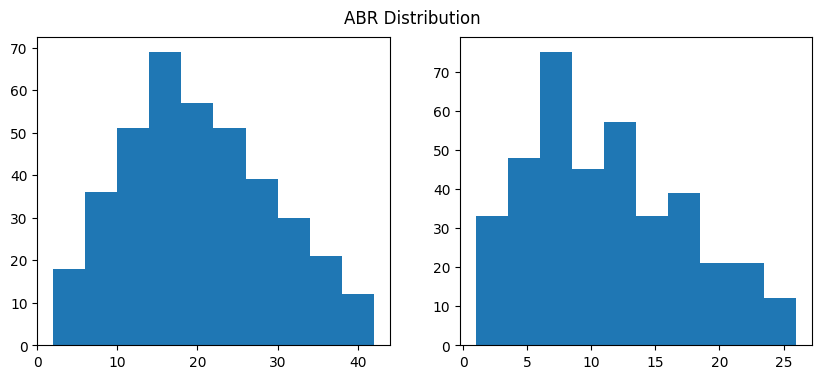

In [189]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure

# Inputs
od_abrs = [od["abr"] for od in on_demand_inputs]
pro_abrs = [pro["abr"] for pro in prophylaxis_inputs]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# Adding type hints as it did not automatically detected
fig: Figure
ax1: Axes
ax2: Axes
ax1.hist(od_abrs)
ax2.hist(pro_abrs)
fig.text(0.5, 0.95, "ABR Distribution",va="top", ha="center", fontsize=12)